# Mini Project 3 Starter Code

This starter code should provide a working example to assist you with parts B through D of MP3. Feel free to use any, all, or none of the code below. Let me know if I have accidentally introduced any bugs!

-- Wesley
___

The only non-standard library used that is not included with the code is ```pandas```. If you don't have this installed in your local environment, uncomment and run the cell below.

In [25]:
# !pip install pandas

Now we load in some custom functions and data structures I have provided to help you with the project.

The ```helpers``` file is used to parse the route schedule csv files, and to cut route schedules into their Bus Tasks.
The ```data_structures``` file contains some custom data structures for Bus Tasks, Bus Runs, Driver Tasks, and Driver Jobs.  I will go over these in more detail in class, but I suggest you open the Python files and explore the functionality yourself.

In [26]:
from helpers import clean_df_from_schedule, create_bus_task_lists, make_deadhead_calculator 
from data_structures import BusTask, BusRun, DriverTask, DriverJob

Now let's load in the csv files. You should have your csv files in the same folder as this Jupyter Notebook.

In [27]:
route_7 = clean_df_from_schedule("MP3_7.csv")
route_18 = clean_df_from_schedule("MP3_18.csv")
route_52 = clean_df_from_schedule("MP3_52.csv")
deadhead = clean_df_from_schedule("MP3_deadheading.csv")

Each route's schedule is loaded into a ```pandas``` dataframe, which can be accessed in the typical manner. For example, below are the first 8 rows of the Route 7 schedule.

In [28]:
route_52.head(n=8)

,0,1,2,3,4,5
0,﻿52 Northbound,,,52 Southbound,,
1,Bancroft & Telegraph,University & Shattuck,El Cerrito Plaza BART,El Cerrito Plaza BART,University & Shattuck,Bancroft & Telegraph
2,6:00 AM,6:12 AM,6:41 AM,5:42 AM,6:21 AM,6:32 AM
3,6:27 AM,6:39 AM,7:16 AM,6:37 AM,7:09 AM,7:20 AM
4,7:00 AM,7:12 AM,7:41 AM,6:55 AM,7:27 AM,7:38 AM
5,7:30 AM,7:42 AM,8:19 AM,7:03 AM,7:35 AM,7:46 AM
6,8:00 AM,8:12 AM,8:41 AM,7:24 AM,7:56 AM,8:07 AM
7,8:30 AM,8:42 AM,9:13 AM,7:38 AM,8:10 AM,8:21 AM


Similarly, we can access the deadheading time table.

In [29]:
deadhead

,0,1,2,3,4,5,6,7
0,﻿Travel Time (min),To: Emeryville Depot,To: Berkeley BART,To: Del Norte BART,To: Mountain & Moraga,To: San Pablo & Marin,To: Bancroft & Telegraph,To: El Cerrito Plaza BART
1,From: Emeryville Depot,0,10,18,14,10,11,15
2,From: Berkeley BART,10,0,15,18,9,3,12
3,From: Del Norte BART,17,14,0,31,8,17,7
4,From: Mountain & Moraga,14,16,28,0,20,15,25
5,From: San Pablo & Marin,11,7,8,23,0,10,5
6,From: Bancroft & Telegraph,11,2,16,17,10,0,13
7,From: El Cerrito Plaza BART,14,11,6,27,5,14,0


I've created a function that allows you to easily lookup the deadhead time by simply providing the origin and destination. The ```make_deadhead_calculator``` function takes in the deadhead table an an input. 

In [30]:
# lets use a function that takes in the origin and destination and returns the deadhead time. We'll feed in the deadhead table once to set it up.

deadhead_time = make_deadhead_calculator(deadhead)



You can then find the deadhead time by entering the origin and destination as strings into the ```deadhead_time``` function. You do *not* need to run ```make_deadhead_calculator``` again. An example of the use of ```deadhead_time``` is provided below.

In [31]:
deadhead_time("Emeryville Depot", "Berkeley BART")

10

# Splitting Route Schedules into Bus Tasks

The helper function ```create_bus_task_lists``` is used below, which takes in the route schedule dataframes as input and returns a list of Bus Tasks for each route. This function follows the schedule cutting procedure outlined in Flowchart 2.

The output lists of Bus Tasks for each route are sorted by start time. Both Northbound and Southbound Bus Tasks are combined in the same output list.

*Note: All times have been converted to "minutes after midnight". This is because some Bus Tasks end after midnight (see example below).*

In [32]:
route_7_tasks, route_18_tasks, route_52_tasks = create_bus_task_lists(route_7, route_52, route_52)

In [33]:
route_tasks = route_7_tasks + route_18_tasks + route_52_tasks
sorted(route_tasks, key=lambda x: x.start_time, reverse=False)

[BusTask(origin='El Cerrito Plaza BART', start_time=342.0, destination='Bancroft & Telegraph', end_time=392.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=50.0),
 BusTask(origin='El Cerrito Plaza BART', start_time=342.0, destination='Bancroft & Telegraph', end_time=392.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=50.0),
 BusTask(origin='Berkeley BART', start_time=360, destination='Del Norte BART', end_time=392, time_at_berkeley_BART=360, task_direction='NB', task_duration=32),
 BusTask(origin='Bancroft & Telegraph', start_time=360, destination='El Cerrito Plaza BART', end_time=401, time_at_berkeley_BART=None, task_direction='NB', task_duration=41),
 BusTask(origin='Bancroft & Telegraph', start_time=360, destination='El Cerrito Plaza BART', end_time=401, time_at_berkeley_BART=None, task_direction='NB', task_duration=41),
 BusTask(origin='Del Norte BART', start_time=370, destination='Berkeley BART', end_time=404, time_at_berkeley_BART=404, task_dir

In [34]:
# For example, we can access the first five BusTasks for Route 7, sorted by start time. Notice NB and SB tasks are in the same list. 
route_52_tasks[:]

[BusTask(origin='El Cerrito Plaza BART', start_time=342.0, destination='Bancroft & Telegraph', end_time=392.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=50.0),
 BusTask(origin='Bancroft & Telegraph', start_time=360, destination='El Cerrito Plaza BART', end_time=401, time_at_berkeley_BART=None, task_direction='NB', task_duration=41),
 BusTask(origin='Bancroft & Telegraph', start_time=387, destination='El Cerrito Plaza BART', end_time=436, time_at_berkeley_BART=None, task_direction='NB', task_duration=49),
 BusTask(origin='El Cerrito Plaza BART', start_time=397.0, destination='Bancroft & Telegraph', end_time=440.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=43.0),
 BusTask(origin='El Cerrito Plaza BART', start_time=415.0, destination='Bancroft & Telegraph', end_time=458.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=43.0),
 BusTask(origin='Bancroft & Telegraph', start_time=420, destination='El Cerrito Plaza BART', end_time=461, 

In [35]:
# the first five BusTasks for Route 7 NB only, sorted by start time
[task for task in route_52_tasks if task.task_direction == 'NB'][0:5]

[BusTask(origin='Bancroft & Telegraph', start_time=360, destination='El Cerrito Plaza BART', end_time=401, time_at_berkeley_BART=None, task_direction='NB', task_duration=41),
 BusTask(origin='Bancroft & Telegraph', start_time=387, destination='El Cerrito Plaza BART', end_time=436, time_at_berkeley_BART=None, task_direction='NB', task_duration=49),
 BusTask(origin='Bancroft & Telegraph', start_time=420, destination='El Cerrito Plaza BART', end_time=461, time_at_berkeley_BART=None, task_direction='NB', task_duration=41),
 BusTask(origin='Bancroft & Telegraph', start_time=450, destination='El Cerrito Plaza BART', end_time=499, time_at_berkeley_BART=None, task_direction='NB', task_duration=49),
 BusTask(origin='Bancroft & Telegraph', start_time=480, destination='El Cerrito Plaza BART', end_time=521, time_at_berkeley_BART=None, task_direction='NB', task_duration=41)]

In [36]:
# The last 5 BusTasks for Route 18. Notice the last 3 bus tasks end after midnight on the next day
route_52_tasks[-6:-1]

[BusTask(origin='Bancroft & Telegraph', start_time=1315, destination='El Cerrito Plaza BART', end_time=1356, time_at_berkeley_BART=None, task_direction='NB', task_duration=41),
 BusTask(origin='El Cerrito Plaza BART', start_time=1316.0, destination='Bancroft & Telegraph', end_time=1360.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=44.0),
 BusTask(origin='El Cerrito Plaza BART', start_time=1346.0, destination='Bancroft & Telegraph', end_time=1390.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=44.0),
 BusTask(origin='Bancroft & Telegraph', start_time=1347, destination='El Cerrito Plaza BART', end_time=1388, time_at_berkeley_BART=None, task_direction='NB', task_duration=41),
 BusTask(origin='El Cerrito Plaza BART', start_time=1378.0, destination='Bancroft & Telegraph', end_time=1422.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=44.0)]

In [37]:
len(route_52_tasks)

93

# Assigning Bus Tasks to Bus Runs

We use Route 7 as an example for the remainder of the starter code. You will need to implement the following parts for route 18 and route 52 independently, and then for all 3 routes with bus tasks pooled together.

The code block below iterates over the Bus Tasks for the route, creating one Bus Run at a time and greedily assigning as many Bus Tasks to it as is feasible. The greedy algorithm will be discussed in greater detail in class.

For this starter code, we provide only a bare bones feasibility check -- a bus task can be assigned to a bus run either if the bus run is empty (i.e., first bus task of the run), or if the latest bus task in the bus run ends before the start time of the bus task we're considering *and* the latest bus task's destination and the origin of the bus task we're considering is the same location.

For part B and C on the project, you will need to expand the feasibility check to incorporate the ability for Bus Runs to be assigned tasks to deadhead to a different location and/or the depot (in order to minimize dwell time).

In [ ]:
#1 Bus Task Fesibility Check
##. Original
#Extend the starter version. A task is feasible if the bus can reach its origin in time for the scheduled departure.
def bus_task_feasibility_check(bus_run, bus_task):
    latest_task = bus_run.get_latest_task()
    if bus_run.is_empty():
        return True
    elif (latest_task.get_end_time() <= bus_task.get_start_time()) and (latest_task.get_destination() == bus_task.get_origin()):
        return True 
    else:
        return False
##. Extended

def bus_task_feasibility_check(bus_run, bus_task):

    latest_task = bus_run.get_latest_task()
    if bus_run.is_empty():
        return True
    elif (latest_task.get_end_time() <= bus_task.get_start_time()) and \
        (latest_task.get_destination() == bus_task.get_origin()):
        return True 
    elif (
        latest_task.get_end_time() <= bus_task.get_start_time()) and \
        (deadhead_time(latest_task.get_destination(),bus_task.get_origin()) <= \
         (bus_task.get_start_time()-latest_task.get_end_time())):
        return True
    else:
        return False
    
    #2 Bus Deadhead Feasibility Check
##Returns “True” if the next task starts at a different location than where the last task ended, meaning a deadhead leg is needed.
def bus_deadhead_feasibility_check(bus_run, bus_task):
    if bus_run.is_empty():
        return False
    latest_task = bus_run.get_latest_task()
    if (
        (latest_task.get_end_time() <= bus_task.get_start_time()) and \
        (deadhead_time(latest_task.get_destination(),bus_task.get_origin()) <= \
         (bus_task.get_start_time())-latest_task.get_end_time()) and \
        (latest_task.get_destination() != bus_task.get_origin())
    ):
        return True
    else:
        return False
    
#3 Add deadhead task
def add_deadhead(bus_run, bus_task):
    latest_task = bus_run.get_latest_task()
    
    origin = latest_task.get_destination()
    destination = bus_task.get_origin()
    
    start_time = latest_task.get_end_time()

    travel_time = deadhead_time(origin, destination)
    end_time = start_time + travel_time
    

    return BusTask(
        origin=origin,
        destination=destination,
        start_time=start_time,
        end_time=end_time,
        task_duration=travel_time,
        task_direction='deadhead' 
    )
    
    #Plot Gantt 

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_bus_gantt(bus_runs):
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Updated Colors
    colors = {
        'NB': "#249c14",       
        'SB': "#e3ee0c",       
        'deadhead': "#959698", 
        'depot': "#090A0A"         
    }
    
    for i, bus_run in enumerate(bus_runs):
        for task in bus_run.get_task_list():
            start = task.get_start_time()
            duration = task.get_task_duration()
            
            # Check direction
            d = task.task_direction
            # Use the direction for color, default to deadhead
            color = colors.get(d, colors['deadhead'])
            
            ax.broken_barh([(start, duration)], (i - 0.4, 0.8), 
                           facecolors=color, edgecolor='black', linewidth=0.5)

    ax.set_yticks(range(len(bus_runs)))
    ax.set_yticklabels([f'Bus {i+1}' for i in range(len(bus_runs))])
    ax.set_xlabel('Time (Minutes from Midnight)')
    ax.set_title('Bus Runs Gantt Chart')
    
    legend_elements = [Patch(facecolor=colors[k], label=k) for k in colors]
    ax.legend(handles=legend_elements, title="Task Type", loc='upper right')
    
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [39]:
def calculate_bus_metrics(bus_runs):
    total_minutes = 0
    
    print(f"{'Run Index':<12} | {'Start':<8} | {'End':<8} | {'Duration (Hrs)':<15}")
    print("-" * 50)
    
    for i, run in enumerate(bus_runs):
        if run.is_empty():
            continue
            
        # Get the very first and very last tasks
        first_task = run.get_first_task()
        last_task = run.get_last_task()
        
        start_time = first_task.get_start_time()

        end_time = last_task.get_end_time()
        
        duration_mins = end_time - start_time
        duration_hrs = duration_mins / 60
        
        total_minutes += duration_mins
        
        print(f"Bus {i+1:<8} | {start_time:<8} | {end_time:<8} | {duration_hrs:<15.2f}")
    
    total_hours = total_minutes / 60
    print("-" * 50)
    print(f"TOTAL BUS HOURS: {total_hours:.2f} hours")
    return total_hours



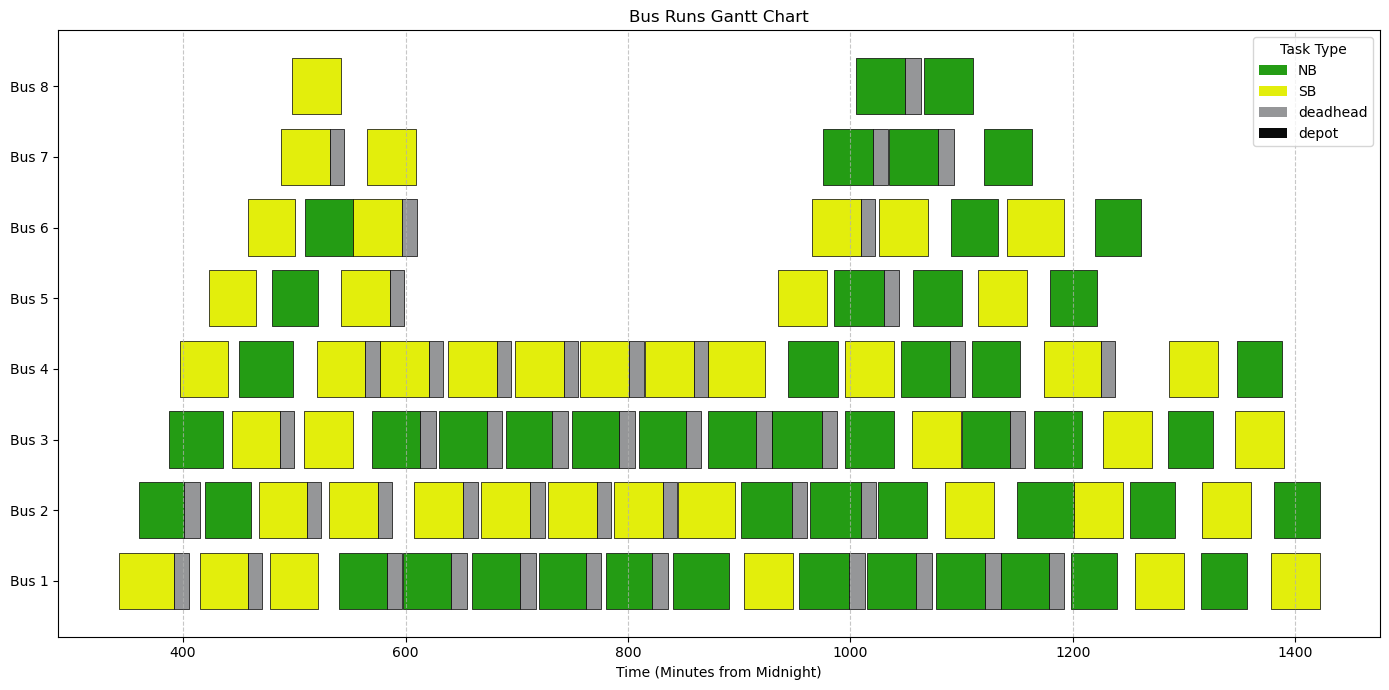

Run Index    | Start    | End      | Duration (Hrs) 
--------------------------------------------------
Bus 1        | 342.0    | 1422.0   | 18.00          
Bus 2        | 360      | 1422     | 17.70          
Bus 3        | 387      | 1390.0   | 16.72          
Bus 4        | 397.0    | 1388     | 16.52          
Bus 5        | 423.0    | 1222     | 13.32          
Bus 6        | 458.0    | 1261     | 13.38          
Bus 7        | 488.0    | 1163     | 11.25          
Bus 8        | 498.0    | 1110     | 10.20          
--------------------------------------------------
TOTAL BUS HOURS: 117.08 hours


In [40]:
bus_tasks = route_52_tasks
bus_tasks.sort(key=lambda x: x.get_start_time())

assigned_tasks = set()
unassigned_tasks = len(bus_tasks)
route_52_bus_runs = []
while unassigned_tasks:
    bus_run = BusRun()
    for task_idx, bus_task in enumerate(bus_tasks):
        if task_idx not in assigned_tasks:
            if bus_task_feasibility_check(bus_run, bus_task):
                if bus_deadhead_feasibility_check(bus_run, bus_task):
                    dh_leg = add_deadhead(bus_run,bus_task)
                    bus_run.add_back(dh_leg)
                bus_run.add_back(bus_task)
                assigned_tasks.add(task_idx)
                unassigned_tasks -= 1
    route_52_bus_runs.append(bus_run)
plot_bus_gantt(route_52_bus_runs)

# Run this after your scheduling loop
total_hrs = calculate_bus_metrics(route_52_bus_runs)



For the barebones feasibility check, we find 3 bus runs are required to cover all of route 7's bus tasks.

In [41]:
len(route_52_bus_runs)

8

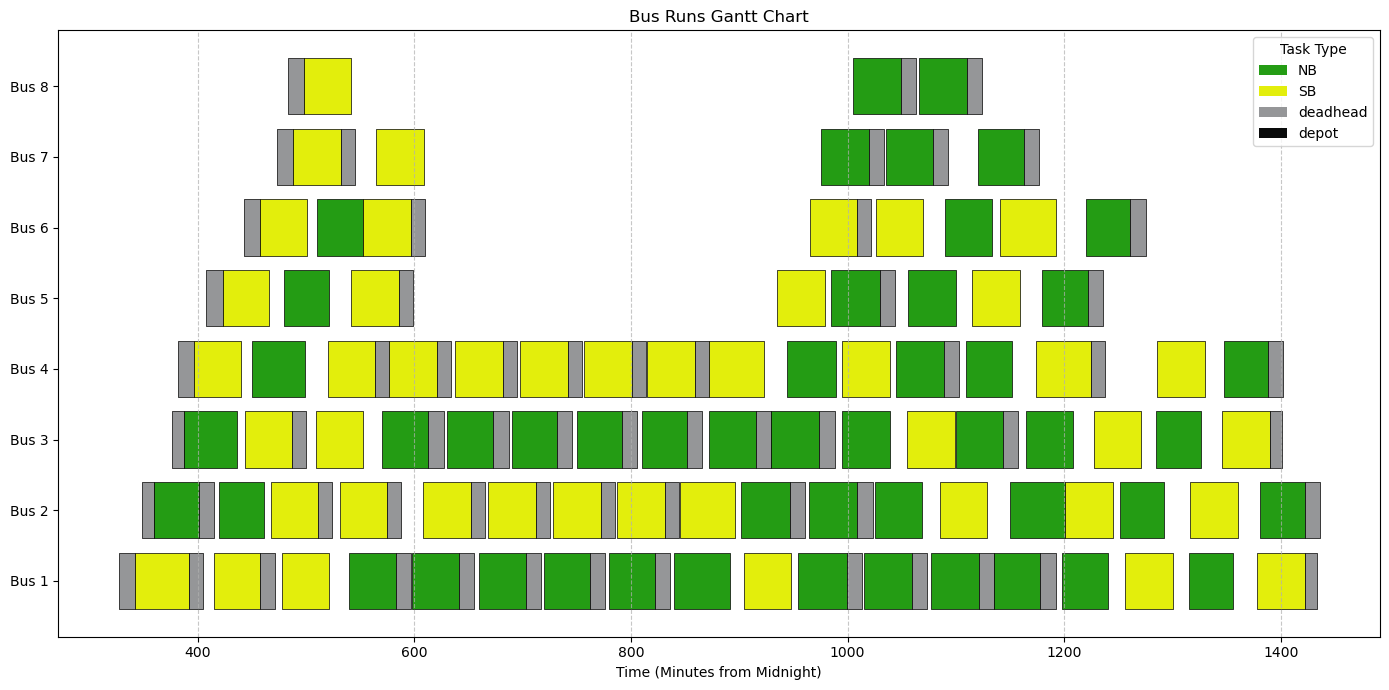

Run Index    | Start    | End      | Duration (Hrs) 
--------------------------------------------------
Bus 1        | 327.0    | 1433.0   | 18.43          
Bus 2        | 349      | 1436     | 18.12          
Bus 3        | 376      | 1401.0   | 17.08          
Bus 4        | 382.0    | 1402     | 17.00          
Bus 5        | 408.0    | 1236     | 13.80          
Bus 6        | 443.0    | 1275     | 13.87          
Bus 7        | 473.0    | 1177     | 11.73          
Bus 8        | 483.0    | 1124     | 10.68          
--------------------------------------------------
TOTAL BUS HOURS: 120.72 hours


In [42]:


bus_tasks = route_52_tasks
bus_tasks.sort(key=lambda x: x.get_start_time())

assigned_tasks = set()
unassigned_tasks = len(bus_tasks)
route_52_bus_runs = []
while unassigned_tasks:
    bus_run = BusRun()
    for task_idx, bus_task in enumerate(bus_tasks):
        if task_idx not in assigned_tasks:
            if bus_task_feasibility_check(bus_run, bus_task):
                if bus_deadhead_feasibility_check(bus_run, bus_task):
                    dh_leg = add_deadhead(bus_run,bus_task)
                    bus_run.add_back(dh_leg)
                bus_run.add_back(bus_task)
                assigned_tasks.add(task_idx)
                unassigned_tasks -= 1
    route_52_bus_runs.append(bus_run)

for bus_run in route_52_bus_runs:
    first_task = bus_run.get_first_task()
    time_to_depart_depot = first_task.get_start_time() - deadhead_time("Emeryville Depot", first_task.get_origin())
    depot_before_first_task = BusTask(origin="Emeryville Depot",
                                      start_time=time_to_depart_depot,
                                      destination=first_task.get_origin(),
                                      end_time=first_task.get_start_time())
    bus_run.add_front(depot_before_first_task)
    last_task = bus_run.get_last_task()
    time_to_arrive_depot = last_task.get_end_time() + deadhead_time(last_task.get_destination(), "Emeryville Depot")
    depot_after_last_task = BusTask(origin=last_task.get_destination(),
                                      start_time=last_task.get_end_time(),
                                      destination="Emeryville Depot",
                                      end_time=time_to_arrive_depot)
    bus_run.add_back(depot_after_last_task)
plot_bus_gantt(route_52_bus_runs)

# Run this after your scheduling loop
total_hrs = calculate_bus_metrics(route_52_bus_runs)



Below is an example of viewing the Bus Tasks assigned to the first Bus Run for route 7.

In [43]:
# this is an example of one bus run for route 7
route_52_bus_runs[0].print_tasks()

BusTask(origin='Emeryville Depot', start_time=327.0, destination='El Cerrito Plaza BART', end_time=342.0, time_at_berkeley_BART=None, task_direction=None, task_duration=15.0)
BusTask(origin='El Cerrito Plaza BART', start_time=342.0, destination='Bancroft & Telegraph', end_time=392.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=50.0)
BusTask(origin='Bancroft & Telegraph', start_time=392.0, destination='El Cerrito Plaza BART', end_time=405.0, time_at_berkeley_BART=None, task_direction='deadhead', task_duration=13)
BusTask(origin='El Cerrito Plaza BART', start_time=415.0, destination='Bancroft & Telegraph', end_time=458.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=43.0)
BusTask(origin='Bancroft & Telegraph', start_time=458.0, destination='El Cerrito Plaza BART', end_time=471.0, time_at_berkeley_BART=None, task_direction='deadhead', task_duration=13)
BusTask(origin='El Cerrito Plaza BART', start_time=478.0, destination='Bancroft & Telegraph', end_tim

Notice the BusRun above starts with the first task at Berkeley BART, and the last task of the run ends at Del Norte BART. However, all Bus Runs must start and end at the Emeryville Depot. Using the ```deadhead_time``` function, we can add a Bus Task from the depot to the first task origin  that lasts the deadheading time between the two locations, and add this as the first Bus Task for the run (using the ```bus_run.add_front``` function). We can do similarly to add a Bus Task from the final task destination to the depot, and add it to the end of the Bus Run.

You may want to use something similar to the code below to implement deadheading between route termini and mid-run dwelling time at the depot.

In [44]:
def bus_depot_feasibility_check(bus_run, bus_task):
    if bus_run.is_empty():
        return False
    latest_task = bus_run.get_latest_task()
    depot = "Emeryville Depot"
    to_depot = deadhead_time(depot,bus_task.get_origin())
    from_depot = deadhead_time(depot,latest_task.get_destination())
    total_travel_required = to_depot + from_depot
    available_gap = bus_task.get_start_time() - latest_task.get_end_time()
    if (available_gap >= total_travel_required):
        return True
    else:
        return False
    
def add_depot_visit(bus_run, bus_task):
    latest_task = bus_run.get_latest_task()
    depot = "Emeryville Depot"
    
    # Task 1: Driving TO the depot
    to_depot_time = deadhead_time(latest_task.get_destination(), depot)
    trip_to_depot = BusTask(
        origin=latest_task.get_destination(),
        destination=depot,
        start_time=latest_task.get_end_time(),
        end_time=latest_task.get_end_time() + to_depot_time,
        task_direction='deadhead'
    )
    
    # Task 2: Driving FROM the depot to the next start
    from_depot_time = deadhead_time(depot, bus_task.get_origin())
    trip_from_depot = BusTask(
        origin=depot,
        destination=bus_task.get_origin(),
        start_time=bus_task.get_start_time() - from_depot_time,
        end_time=bus_task.get_start_time(),
        task_direction='deadhead'
    )

    wait_at_depot = BusTask(
        origin=depot,
        destination=depot,
        start_time=trip_to_depot.get_end_time(),
        end_time=trip_from_depot.get_start_time(),
        task_direction='depot'  
    )
    
    return trip_to_depot, wait_at_depot, trip_from_depot


def calculate_bus_metrics_depot(bus_runs):
    total_operating_mins = 0
    total_dwelling_mins = 0
    total_depot_mins = 0
    total_duration_mins = 0
    
    print(f"{'Run Index':<12} | {'Start':<8} | {'End':<8} | {'Dwell (Hrs)':<10}| {'Depot (Hrs)':<10}| {'Total (Hrs)':<15}")
    print("-" * 75)
    
    for i, run in enumerate(bus_runs):
        if run.is_empty():
            continue
            
        # Get the very first and very last tasks
        first_task = run.get_first_task()
        last_task = run.get_last_task()
        
        start_time = first_task.get_start_time()
        end_time = last_task.get_end_time()
        driving_mins = sum([task.get_task_duration() for task in run.get_task_list() if task.task_direction != 'depot'])
        depot_mins = sum([task.get_task_duration() for task in run.get_task_list() if task.task_direction == 'depot'])
        duration_mins = end_time - start_time
        dwelling_mins = duration_mins - driving_mins - depot_mins
        total_operating_mins += (driving_mins + dwelling_mins)
        total_dwelling_mins += dwelling_mins
        total_depot_mins += depot_mins
        total_duration_mins += duration_mins
        
        
        print(f"Bus {i+1:<8} | {start_time:<8} | {end_time:<8} |  {dwelling_mins/60:<10.2f} | {depot_mins/60:<10.2f} | {duration_mins/60:<10.2f}")
    
    print("-" * 75)
    print(f"Total Duration: {total_duration_mins / 60:.2f} hours")
    print(f"Total Paid Bus Hours: {total_operating_mins / 60:.2f} hours")
    print(f"Total Dwell Time:    {total_dwelling_mins / 60:.2f} hours")    
    print(f"Total Time at Depot:    {total_depot_mins / 60:.2f} hours")

    return total_operating_mins / 60

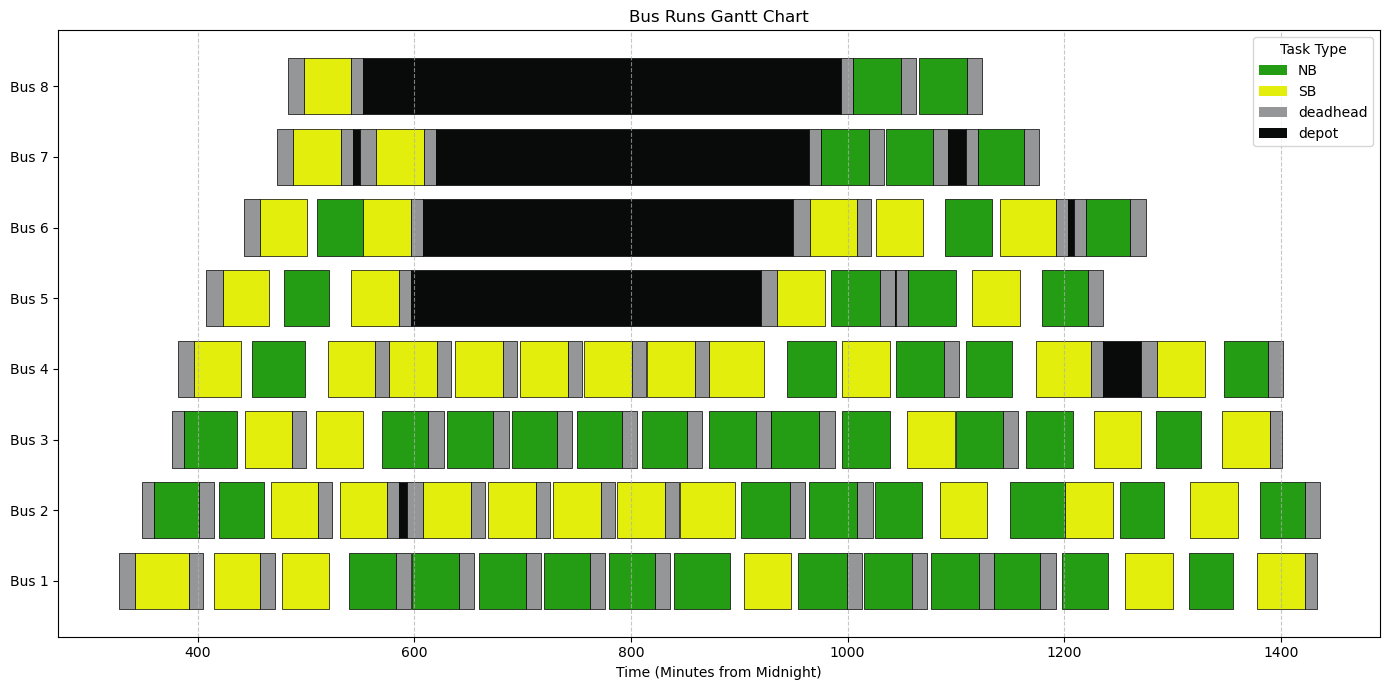

Run Index    | Start    | End      | Dwell (Hrs)| Depot (Hrs)| Total (Hrs)    
---------------------------------------------------------------------------
Bus 1        | 327.0    | 1433.0   |  2.28       | 0.00       | 18.43     
Bus 2        | 349      | 1436     |  2.12       | 0.12       | 18.12     
Bus 3        | 376      | 1401.0   |  2.32       | 0.00       | 17.08     
Bus 4        | 382.0    | 1402     |  1.98       | 0.58       | 17.00     
Bus 5        | 408.0    | 1236     |  1.27       | 5.40       | 13.80     
Bus 6        | 443.0    | 1275     |  0.68       | 5.80       | 13.87     
Bus 7        | 473.0    | 1177     |  0.02       | 6.12       | 11.73     
Bus 8        | 483.0    | 1124     |  0.05       | 7.35       | 10.68     
---------------------------------------------------------------------------
Total Duration: 120.72 hours
Total Paid Bus Hours: 95.35 hours
Total Dwell Time:    10.72 hours
Total Time at Depot:    25.37 hours


95.35

In [46]:
bus_tasks = route_52_tasks
bus_tasks.sort(key=lambda x: x.get_start_time())

assigned_tasks = set()
unassigned_tasks = len(bus_tasks)
route_52_bus_runs = []
while unassigned_tasks:
    bus_run = BusRun()
    for task_idx, bus_task in enumerate(bus_tasks):
        if task_idx not in assigned_tasks:
            if bus_task_feasibility_check(bus_run, bus_task):
                if bus_depot_feasibility_check(bus_run, bus_task):
                    to_depot, wait, from_depot = add_depot_visit(bus_run, bus_task)
                    bus_run.add_back(to_depot)       
                    bus_run.add_back(wait)  
                    bus_run.add_back(from_depot)
                
                elif bus_deadhead_feasibility_check(bus_run, bus_task):
                    dh_leg = add_deadhead(bus_run, bus_task)
                    bus_run.add_back(dh_leg)

                bus_run.add_back(bus_task)
                assigned_tasks.add(task_idx)
                unassigned_tasks -= 1
    route_52_bus_runs.append(bus_run)

for bus_run in route_52_bus_runs:
    first_task = bus_run.get_first_task()
    time_to_depart_depot = first_task.get_start_time() - deadhead_time("Emeryville Depot", first_task.get_origin())
    depot_before_first_task = BusTask(origin="Emeryville Depot",
                                      start_time=time_to_depart_depot,
                                      destination=first_task.get_origin(),
                                      end_time=first_task.get_start_time())
    bus_run.add_front(depot_before_first_task)
    last_task = bus_run.get_last_task()
    time_to_arrive_depot = last_task.get_end_time() + deadhead_time(last_task.get_destination(), "Emeryville Depot")
    depot_after_last_task = BusTask(origin=last_task.get_destination(),
                                      start_time=last_task.get_end_time(),
                                      destination="Emeryville Depot",
                                      end_time=time_to_arrive_depot)
    bus_run.add_back(depot_after_last_task)
    
plot_bus_gantt(route_52_bus_runs)
calculate_bus_metrics_depot(route_52_bus_runs)



In [47]:
# now we see that the start and end tasks at the depot have been added
route_52_bus_runs[0].print_tasks()

BusTask(origin='Emeryville Depot', start_time=327.0, destination='El Cerrito Plaza BART', end_time=342.0, time_at_berkeley_BART=None, task_direction=None, task_duration=15.0)
BusTask(origin='El Cerrito Plaza BART', start_time=342.0, destination='Bancroft & Telegraph', end_time=392.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=50.0)
BusTask(origin='Bancroft & Telegraph', start_time=392.0, destination='El Cerrito Plaza BART', end_time=405.0, time_at_berkeley_BART=None, task_direction='deadhead', task_duration=13)
BusTask(origin='El Cerrito Plaza BART', start_time=415.0, destination='Bancroft & Telegraph', end_time=458.0, time_at_berkeley_BART=None, task_direction='SB', task_duration=43.0)
BusTask(origin='Bancroft & Telegraph', start_time=458.0, destination='El Cerrito Plaza BART', end_time=471.0, time_at_berkeley_BART=None, task_direction='deadhead', task_duration=13)
BusTask(origin='El Cerrito Plaza BART', start_time=478.0, destination='Bancroft & Telegraph', end_tim

Ultimately, we want to find the bus-hrs spent in operation and dwelling (as the goal of the assignment is to minimize wasted dwell time). We can calculate the total operating time for route 7 by finding the start and end time for each Bus Run, taking the difference, and summing it over all Bus Runs. Total dwelling time can be found by subtracting the task duration for each Bus Task in each Bus Run from the operating time of each Bus Task, and summing over all Bus Runs. 

In [104]:
# total operating and dwelling time
total_operating_time = 0
total_dwelling_time = 0
for bus_run in route_7_bus_runs:
    operating_time = bus_run.get_last_task().get_end_time() - bus_run.get_first_task().get_start_time()
    driving_time = sum([task.get_task_duration() for task in bus_run.get_task_list()])
    dwelling_time = operating_time - driving_time
    total_operating_time += operating_time
    total_dwelling_time += dwelling_time

print(f"Total operating time: {total_operating_time/60}")
print(f"Total dwelling time: {total_dwelling_time/60}")

Total operating time: 44.46666666666667
Total dwelling time: 5.316666666666666


# Cutting Bus Runs into Driver Tasks

Each Bus Run can be cut into Driver Tasks, which will later be assigned to form Driver Jobs. A Driver Task is the smallest portion of a Bus Run (i.e. collection of Bus Tasks) such that it starts and ends at one of the driver exchange points, Emeryville Depot and Berkeley BART.

We provide a simple implementation that loops through the the Bus Tasks for each Bus Run and checks if the bus task ends at a driver exchange point. We know the first task of each bus run starts at a driver exchange point, so the start time and origin are recorded. Then, each proceeding Bus Task is checked. If the bus task Ends at an exchange point, then a Driver Task is created, started from the recorded start time and origin and ending at the ending Bus Task's end time and destination. The Driver Task is saved, and then the variables for the recorded start time and origin (for the next Driver Task) are updated to equal the previous ending Bus Task's end time and destination. The loop proceeds until all Bus Tasks in a Bus Run have been collected to form Driver Tasks.

To simplify calculations later on, the time a driver spends driving (as opposed to dwelling) is calculated for each Driver Task. 

*Note:* Our implementation *does not* include the possibility of mid-Bus Task driver exchanges, i.e., route 18 Bus Tasks have Berkeley BART as a location along its route but not as a route terminus. Your implementations involving route 18 should allow for the possibility of a Driver Task to start or end in the middle of a route 18 Bus Task, as well as when Berkeley BART is a route terminus or the Emeryville Depot.

In [99]:
route_7_driver_tasks = []
driver_exchange_points = {"Emeryville Depot", "Berkeley BART"}
for bus_run in route_7_bus_runs:
    start_time = bus_run.get_first_task().get_start_time()
    origin_location = bus_run.get_first_task().get_origin()
    driver_driving_time = 0
    for bus_task in bus_run.get_task_list():
        driver_driving_time += bus_task.get_task_duration()
        if bus_task.get_destination() in driver_exchange_points:
            driver_task = DriverTask(origin=origin_location,
                                     start_time=start_time,
                                     destination=bus_task.get_destination(),
                                     end_time=bus_task.get_end_time(),
                                     time_spent_driving=driver_driving_time)
            route_7_driver_tasks.append(driver_task)
            start_time = bus_task.get_end_time()
            origin_location = bus_task.get_destination()
            driver_driving_time = 0

            


In [100]:
# All driver tasks for route 7
route_7_driver_tasks

[DriverTask(origin='Emeryville Depot', start_time=350, destination='Berkeley BART', end_time=360, time_spent_driving=10),
 DriverTask(origin='Berkeley BART', start_time=360, destination='Berkeley BART', end_time=439, time_spent_driving=66),
 DriverTask(origin='Berkeley BART', start_time=439, destination='Emeryville Depot', end_time=449, time_spent_driving=10),
 DriverTask(origin='Emeryville Depot', start_time=449, destination='Emeryville Depot', end_time=462, time_spent_driving=13),
 DriverTask(origin='Emeryville Depot', start_time=462, destination='Berkeley BART', end_time=472, time_spent_driving=10),
 DriverTask(origin='Berkeley BART', start_time=472, destination='Berkeley BART', end_time=560, time_spent_driving=68),
 DriverTask(origin='Berkeley BART', start_time=560, destination='Emeryville Depot', end_time=570, time_spent_driving=10),
 DriverTask(origin='Emeryville Depot', start_time=570, destination='Emeryville Depot', end_time=584, time_spent_driving=14),
 DriverTask(origin='Emer

# Assigning Driver Tasks to Driver Jobs

A similar procedure as Bus Task assignment is used to greedily assign Driver Tasks to Driver Jobs. A Driver Job is simply a collection of Driver Tasks that one driver would complete in a work shift. However, in addition to checking that a Driver Task can feasibly be added to a Driver Job (by checking start and end locations and times), we must make sure that adding the task would not make the Driver Job go over the maximum shift length. In the code provided, a shift length of 8 hours is used.

A Driver Task puts a Driver Job into overtime if: it is the first Driver Task of the Driver Job and it has a duration greater than the maximum shift length;  if adding the Driver Task to the existing Driver Job makes the job duration greater than the shift length; or if adding the Driver Task would create a split shift (i.e., working in non-consecutive parts of the day with a total working duration greater than the maximum shift length).

You will need to expand the code provided to allow for drivers to potentially work overtime (if it would be cheaper than hiring a new driver for a full 8 hour shift), and to support the different types of shift lengths described in the assignment. 

In [22]:
def would_make_driver_job_overtime(driver_job, driver_task):
    if driver_job.is_empty():
        return driver_task.get_task_duration() > driver_job.get_shift_length()
    else:
        # assume no split shifts
        return ((driver_job.get_last_task().get_end_time() - driver_job.get_first_task().get_start_time()) + driver_task.get_task_duration() > driver_job.get_shift_length()) or \
                (driver_task.get_end_time() - driver_job.get_first_task().get_start_time() > driver_job.get_shift_length())

def driver_task_feasibility_check(driver_job, driver_task):
    latest_task = driver_job.get_latest_task()
    if driver_job.is_empty():
        return True
    elif (latest_task.get_end_time() <= driver_task.get_start_time()) and (latest_task.get_destination() == driver_task.get_origin()):
        return True 
    else:
        return False



driver_tasks = sorted(route_7_driver_tasks, key=lambda x: x.get_start_time(), reverse=False)
assigned_tasks = set()
unassigned_tasks = len(driver_tasks)
route_7_driver_jobs = []
while unassigned_tasks:
    driver_job = DriverJob(shift_length=8)
    for task_idx, driver_task in enumerate(driver_tasks):
        if task_idx not in assigned_tasks:
            if would_make_driver_job_overtime(driver_job, driver_task) == False:
                if driver_task_feasibility_check(driver_job, driver_task):
                    driver_job.add_back(driver_task)
                    assigned_tasks.add(task_idx)
                    unassigned_tasks -= 1
    route_7_driver_jobs.append(driver_job)



We can see below that 7 drivers will be needed to cover the route 7 driver jobs.

In [23]:
len(route_7_driver_jobs)

7

In [24]:
# Example of one route 7 driver job
route_7_driver_jobs[0].print_tasks()

DriverTask(origin='Emeryville Depot', start_time=350, destination='Berkeley BART', end_time=360, time_spent_driving=10)
DriverTask(origin='Berkeley BART', start_time=360, destination='Berkeley BART', end_time=439, time_spent_driving=66)
DriverTask(origin='Berkeley BART', start_time=439, destination='Berkeley BART', end_time=560, time_spent_driving=68)
DriverTask(origin='Berkeley BART', start_time=560, destination='Berkeley BART', end_time=680, time_spent_driving=68)
DriverTask(origin='Berkeley BART', start_time=680, destination='Berkeley BART', end_time=800, time_spent_driving=68)


The assignment asks for the driver hours wasted (i.e., total time drivers do not spend driving) and the cost for covering the runs. You can see below that 17.46 driver-hours are wasted and it will cost $1086.67 to cover all of the runs. 

In [25]:
total_wasted_time = 0
total_running_time = 0
for driver_job in route_7_driver_jobs:
    for driver_task in driver_job.get_task_list():
        running_time = driver_task.get_end_time() - driver_task.get_start_time()
        wasted_time = running_time - driver_task.get_time_spent_driving()
        total_running_time += running_time
        total_wasted_time += wasted_time

print(f"Total wasted time: {total_wasted_time/60} driver-hrs")
print(f"Total cost to cover Route 7 runs: ${len(route_7_driver_jobs)*8*25}")

Total wasted time: 17.466666666666665 driver-hrs
Total cost to cover Route 7 runs: $1400
